# Allen-Cahn equation

### Configuration

In [1]:
from __init__ import create_config, figures
from IPython.display import display

/Users/flo/Documents/Documents - 619/studies/mathematics_msc/MASTERTHESIS/AdHoc/figures.py:781: SyntaxWarning: invalid escape sequence '\m'
  ylabel: str = "$\mathcal{L}$",


In [2]:
config = create_config(
    system="allen_cahn",
    n_states=16,
    n_controls=2,
    t1_initial=3.0,
    t1_max=10.0,
    seed=42,
)

figures.save_config_table(config)
figures.show_spec(
    config, 
    keys=["system", "seed", "n_states", "n_controls", "t1_initial", "nu"],
    title="Allen-Cahn configuration"
)

**Allen-Cahn configuration**

system,seed,n_states,n_controls,t1_initial,nu
allen_cahn,42,16,2,3.000000,0.150000


### Data Generation

In [3]:
controller_configs_ac = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
}


Solving open loop OCPs...

 attempted |  solved   |  desired  
-----------------------------------


$N_{\mathrm{traj}}$,$|\mathcal{D}|$,t (max),|x| (mean),|x| (max),$\|x\|$ (mean),$\|x\|$ (max)
10,681,3.148862,0.146161,0.857019,0.232871,0.657781


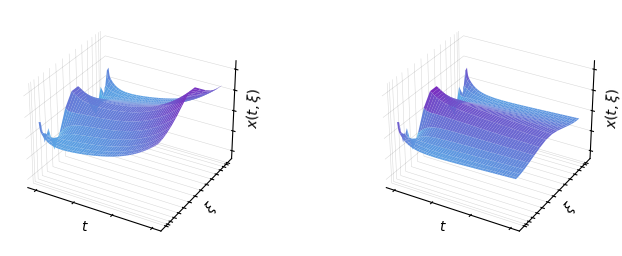

In [4]:
import matplotlib.pyplot as plt
from data import load_or_generate

n_trajectories = 10
n_candidates = 200
n_MC = 10

data_ac_train, data_ac_val, meta_ac = load_or_generate(
    config, n_trajectories=n_trajectories, n_candidates=n_candidates, controller=config.ocp.LQR
)

summary_ac = figures.save_data_summary_table(config, data_ac_train)
display(summary_ac.style.hide(axis="index"))

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### Model Training

**Training Configuration**

sup_epochs,sup_lr,unsup_epochs,unsup_n_steps,unsup_lr,horizon,batch_size,grad_clip
1,0.000010,4,50,0.000500,50,16,None



Training: GradQRNet

Training: GradQRNet (sup)

Training: GradQRNet (pre)

Training: GradQRNet (pre/sup)

Training: GradQRNet (ad)

Training: GradQRNet (sup/ad)


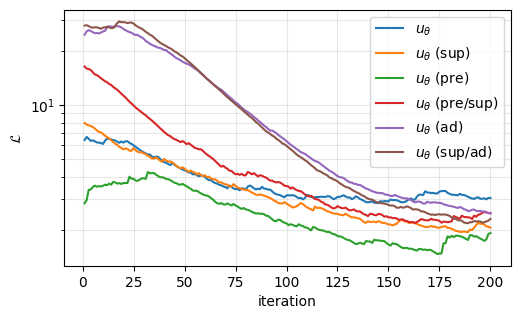

In [5]:
from controls.train import TrainConfig
from controls.model_factory import train_controllers
cfg_ac = TrainConfig(batch_size=int(config.n_states), unsup_epochs=4, horizon=50, unsup_n_steps=50, n_candidates=n_candidates)

figures.save_params_table(cfg_ac, "allen_cahn_traincfg.tex", title="Training configuration", config=config)

figures.show_spec(
    cfg_ac, 
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "grad_clip"], 
    title="Training Configuration"
)


trained_models_ac, trained_controllers_ac, histories_ac = train_controllers(
    config=config,
    train_cfg=cfg_ac,
    data=data_ac_train,
    val_data=data_ac_val,
    controller_configs=controller_configs_ac,  # Use the config defined above
)

figures.plot_training_losses(
    series=[(name, hist) for name, hist in histories_ac.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
    savepath="allen_cahn_loss_curve.pdf",
    config=config,
);
plt.show()

figures.plot_training_val_mse(
    config=config,
    histories=histories_ac,
    controller_configs=controller_configs_ac,
);
plt.show()

In [6]:
controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
] + [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

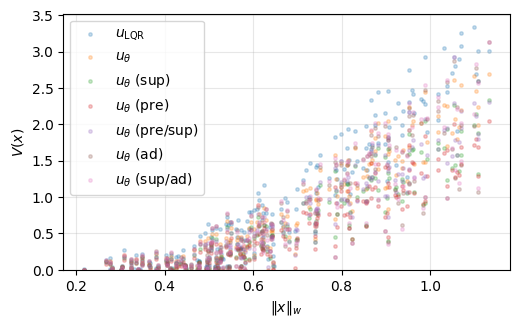

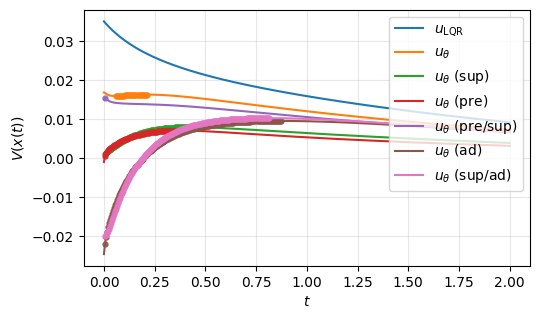

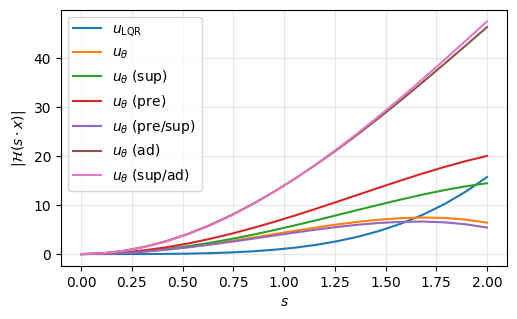

In [7]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
    suffix="_2",
)
plt.show()

In [8]:
from simulation import monte_carlo

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 10/10 [00:00<00:00, 86.89it/s]


Trajectory 0 NOT converged - final_dists[0] = inf
Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


 20%|██        | 2/10 [00:00<00:01,  7.71it/s]

Trajectory 0 NOT converged - final_dists[0] = inf
Trajectory 1 NOT converged - final_dists[1] = inf


 40%|████      | 4/10 [00:00<00:00,  8.16it/s]

...

 10%|█         | 1/10 [00:00<00:01,  8.87it/s]

Trajectory 0 NOT converged - final_dists[0] = inf
Trajectory 1 NOT converged - final_dists[1] = inf


100%|██████████| 10/10 [00:01<00:00,  8.16it/s]


Controller,Stability (S),Cost J (mean),t_conv (mean)
LQR (Baseline),0.0%,N/A,N/A
GradQRNet,0.0%,N/A,N/A
GradQRNet (sup),20.0%,0.1921,10.68
GradQRNet (pre),0.0%,N/A,N/A
GradQRNet (pre/sup),0.0%,N/A,N/A
GradQRNet (ad),70.0%,0.5655,10.18
GradQRNet (sup/ad),30.0%,0.2235,9.81


,Model,Stability $S$,Cost $J$ (mean),$t_{\text{conv}}$ (mean)
0,LQR (Baseline),0.0,NaN,NaN
1,GradQRNet,0.0,NaN,NaN
2,GradQRNet (sup),0.2,0.192138,10.677595
3,GradQRNet (pre),0.0,NaN,NaN
4,GradQRNet (pre/sup),0.0,NaN,NaN
5,GradQRNet (ad),0.7,0.565506,10.180988
6,GradQRNet (sup/ad),0.3,0.223534,9.813415


### Out-of-Sample Generalization

In [9]:
results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC, dist=1.5)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_far.tex")

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 97.69it/s]


Trajectory 0 NOT converged - final_dists[0] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


 10%|█         | 1/10 [00:00<00:01,  6.76it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


...

 30%|███       | 3/10 [00:00<00:00,  8.79it/s]

Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 10/10 [00:01<00:00,  7.37it/s]


Controller,Stability (S),Cost J (mean),t_conv (mean)
LQR (Baseline),10.0%,0.2797,10.75
GradQRNet,0.0%,N/A,N/A
GradQRNet (sup),10.0%,0.2808,10.00
GradQRNet (pre),10.0%,0.2802,10.64
GradQRNet (pre/sup),0.0%,N/A,N/A
GradQRNet (ad),10.0%,0.2857,8.92
GradQRNet (sup/ad),10.0%,0.2844,9.04


,Model,Stability $S$,Cost $J$ (mean),$t_{\text{conv}}$ (mean)
0,LQR (Baseline),0.1,0.279683,10.749542
1,GradQRNet,0.0,NaN,NaN
2,GradQRNet (sup),0.1,0.280763,9.999894
3,GradQRNet (pre),0.1,0.280150,10.644970
4,GradQRNet (pre/sup),0.0,NaN,NaN
5,GradQRNet (ad),0.1,0.285654,8.918277
6,GradQRNet (sup/ad),0.1,0.284427,9.036249


In [10]:
# Basic Monte Carlo: no distance constraint, K=20 for sampling
K_mc = 20
results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC, dist=None, K=K_mc)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_diff.tex")

100%|██████████| 10/10 [00:00<00:00, 99.93it/s]


Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


 10%|█         | 1/10 [00:00<00:01,  7.48it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


 20%|██        | 2/10 [00:00<00:01,  6.56it/s]

...

 30%|███       | 3/10 [00:00<00:00,  7.12it/s]

Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 10/10 [00:01<00:00,  7.06it/s]


Controller,Stability (S),Cost J (mean),t_conv (mean)
LQR (Baseline),20.0%,0.1043,9.41
GradQRNet,10.0%,0.0859,8.75
GradQRNet (sup),20.0%,0.1056,8.97
GradQRNet (pre),20.0%,0.1044,9.32
GradQRNet (pre/sup),0.0%,N/A,N/A
GradQRNet (ad),50.0%,0.3708,9.38
GradQRNet (sup/ad),40.0%,0.2572,9.24


,Model,Stability $S$,Cost $J$ (mean),$t_{\text{conv}}$ (mean)
0,LQR (Baseline),0.2,0.104346,9.405969
1,GradQRNet,0.1,0.085889,8.752318
2,GradQRNet (sup),0.2,0.105556,8.968531
3,GradQRNet (pre),0.2,0.104362,9.318176
4,GradQRNet (pre/sup),0.0,NaN,NaN
5,GradQRNet (ad),0.5,0.370829,9.383863
6,GradQRNet (sup/ad),0.4,0.257205,9.237321


### Model mismatch

In [11]:
from simulation import monte_carlo_nu_mismatch

# Controllers trained on baseline (config.ocp has nu = baseline nu)
controllers_ac = [
    ("LQR", config.ocp.LQR),
] + [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

# Evaluate with reduced ν (model mismatch: harder dynamics)
nu_baseline = config.ocp.nu
nu_eval = 0.149  # reduced diffusion
print(f"Model mismatch: train ν={nu_baseline}, eval ν={nu_eval}")
results = monte_carlo_nu_mismatch(
    config.ocp, config, controllers_ac, nu_eval=nu_eval, n_MC=n_MC, verbose=0
)
figures.show_monte_carlo_results(results)
df = figures.save_monte_carlo_results(
    results, config=config, savepath="monte_carlo_nu_mismatch.tex"
)
display(df.style.hide(axis="index"))

Model mismatch: train ν=0.15, eval ν=0.149


100%|██████████| 10/10 [00:00<00:00, 105.66it/s]


Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


 30%|███       | 3/10 [00:00<00:00,  9.50it/s]

Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


...

 30%|███       | 3/10 [00:00<00:00,  8.32it/s]

Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 10/10 [00:01<00:00,  6.30it/s]


Controller,Stability (S),Cost J (mean),t_conv (mean)
LQR,20.0%,0.0290,6.58
GradQRNet,20.0%,0.0293,7.20
GradQRNet (sup),20.0%,0.0291,6.48
GradQRNet (pre),20.0%,0.0290,6.69
GradQRNet (pre/sup),0.0%,N/A,N/A
GradQRNet (ad),70.0%,0.3614,9.15
GradQRNet (sup/ad),40.0%,0.1530,8.14


Model,Stability $S$,Cost $J$ (mean),$t_{\text{conv}}$ (mean)
LQR,0.200000,0.029008,6.581354
GradQRNet,0.200000,0.029308,7.200533
GradQRNet (sup),0.200000,0.029121,6.479926
GradQRNet (pre),0.200000,0.029020,6.685482
GradQRNet (pre/sup),0.000000,nan,nan
GradQRNet (ad),0.700000,0.361363,9.146141
GradQRNet (sup/ad),0.400000,0.152950,8.136972


### Additive noise

In [12]:
from simulation import monte_carlo

# Same controllers and IC sampling as baseline; add additive noise in rollout
sigma_sde = 0.0003  # noise strength
dt_sde = 5e-3     # Euler-Maruyama step
print(f"SDE Monte Carlo: σ={sigma_sde}, dt={dt_sde}, n_MC={n_MC}")
results = monte_carlo(
    config.ocp, config, controllers,
    n_MC=n_MC, dist=None,
    sigma=sigma_sde, dt_sde=dt_sde, random_seed=42, verbose=1
)
figures.show_monte_carlo_results(results)
df = figures.save_monte_carlo_results(
    results, config=config, savepath="monte_carlo_sde.tex"
)
display(df.style.hide(axis="index"))

SDE Monte Carlo: σ=0.0003, dt=0.005, n_MC=10

Evaluating LQR (Baseline)...


 40%|████      | 4/10 [00:00<00:00, 31.79it/s]

Trajectory 0 NOT converged - final_dists[0] = inf
Trajectory 1 NOT converged - final_dists[1] = inf
Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 10/10 [00:00<00:00, 32.70it/s]



Evaluating GradQRNet...


...

 30%|███       | 3/10 [00:00<00:01,  4.66it/s]

Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 10/10 [00:02<00:00,  4.61it/s]


Controller,Stability (S),Cost J (mean),t_conv (mean)
LQR (Baseline),10.0%,0.1010,10.27
GradQRNet,0.0%,N/A,N/A
GradQRNet (sup),10.0%,0.1020,9.89
GradQRNet (pre),0.0%,N/A,N/A
GradQRNet (pre/sup),0.0%,N/A,N/A
GradQRNet (ad),40.0%,0.2525,9.64
GradQRNet (sup/ad),10.0%,0.1975,9.90


Model,Stability $S$,Cost $J$ (mean),$t_{\text{conv}}$ (mean)
LQR (Baseline),0.100000,0.101033,10.270454
GradQRNet,0.000000,nan,nan
GradQRNet (sup),0.100000,0.101977,9.886185
GradQRNet (pre),0.000000,nan,nan
GradQRNet (pre/sup),0.000000,nan,nan
GradQRNet (ad),0.400000,0.252475,9.637901
GradQRNet (sup/ad),0.100000,0.197496,9.901157


## Scalability

In [13]:
# Burgers with a different nu (e.g. 0.02 instead of default 0.012)
config = create_config(
    system="allen_cahn",
    n_states=64,
    n_controls=2,
    t1_initial=5.0,
    t1_max=10.0,
    seed=39,
    nu=0.17,
)

figures.save_config_table(config)
figures.show_spec(
    config,
    keys=["system", "seed", "n_states", "n_controls", "t1_initial", "nu"],
    title="Burgers configuration (scalability)"
)

**Burgers configuration (scalability)**

system,seed,n_states,n_controls,t1_initial,nu
allen_cahn,39,64,2,5.000000,0.170000


In [14]:
# Only Sup GradQRNet and GradQRNet (sup/ad) for this experiment
controller_configs = {
    "Sup GradQRNet": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
}

In [ ]:
from data import load_or_generate

n_trajectories = 40  # scalability: forty trajectories (thesis)
n_candidates = 200
data_train, data_val, meta = load_or_generate(
    config, n_trajectories=n_trajectories, n_candidates=n_candidates, controller=config.ocp.LQR
)

In [15]:
n_candidates = 200
cfg = TrainConfig(
    batch_size=int(config.n_states),
    horizon=50,
    unsup_n_steps=50,
    unsup_epochs=4,
    sup_epochs=5,
    sup_lr=5e-4,
    n_candidates=n_candidates,
)

figures.show_spec(
    cfg,
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "grad_clip"],
    title="Training Configuration"
)

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,
    val_data=data_val,
    controller_configs=controller_configs,
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
);
plt.show()

**Training Configuration**

sup_epochs,sup_lr,unsup_epochs,unsup_n_steps,unsup_lr,horizon,batch_size,grad_clip
5,0.000500,4,50,0.000500,50,64,None


NameError: name 'data_train' is not defined

In [ ]:
controllers = [
    ("LQR", config.ocp.LQR),
] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_scalability.tex")